# Зависимость косинусного расстояния в PCA от перцептивных расстояний

LM Embed shape(1755, 3584)
LM PCA 99-comp shape(1755, 33)
VL Embed shape(1755, 3584)
VL PCA 99-comp shape(1755, 19)


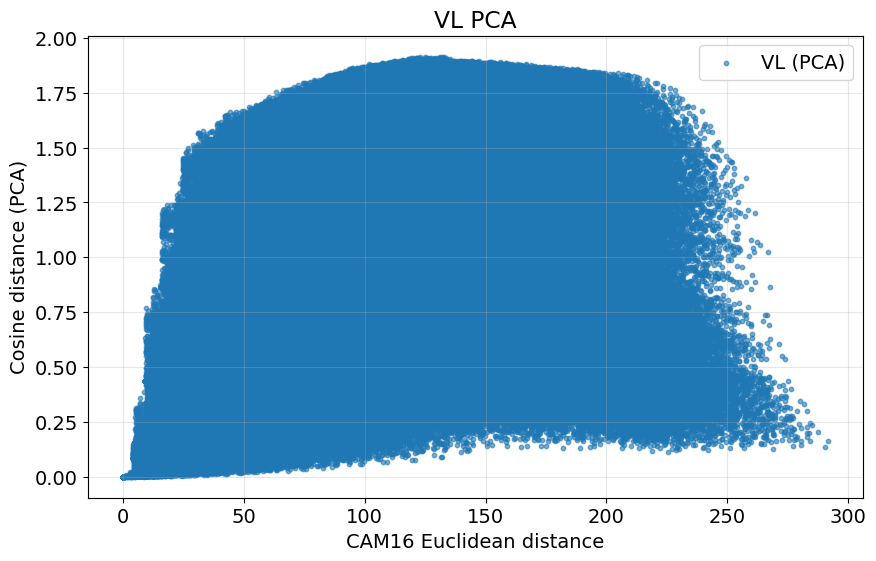

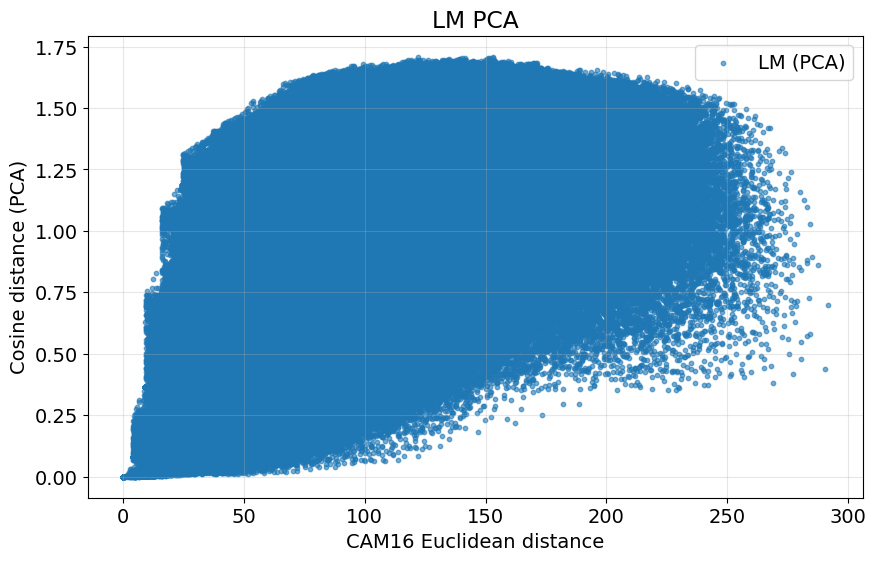

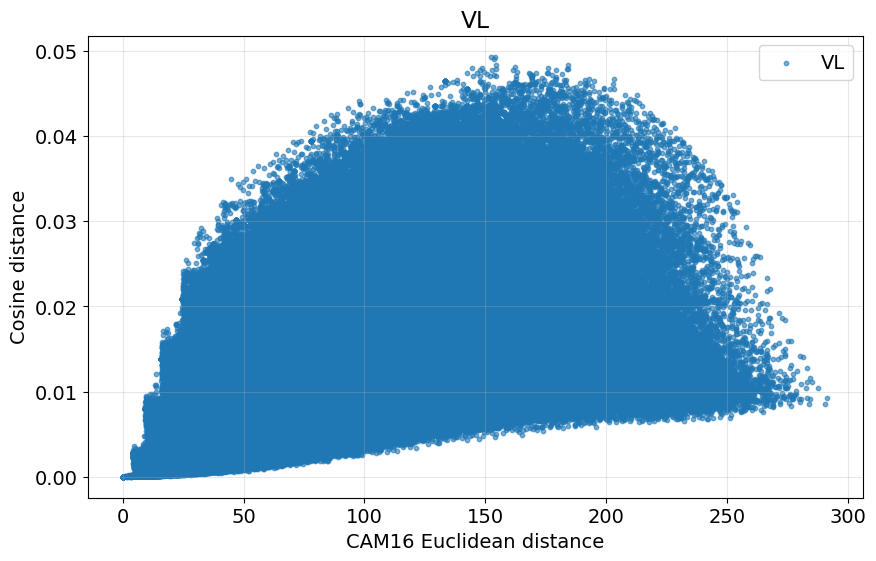

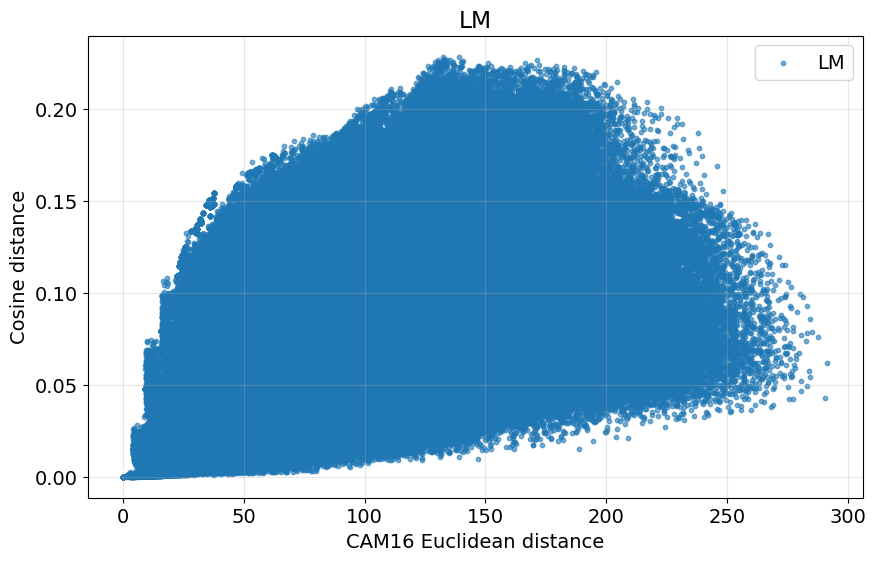

In [2]:
from scipy.spatial.distance import cosine
from colour import xyY_to_XYZ
from colour.models import XYZ_to_CAM16LCD
import numpy as np
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
from utils.analyze.munsell_analyze import MunsellEmbeddingsAnalyzer

analyzer = MunsellEmbeddingsAnalyzer('data/embeddings/qwen2.5_7B/munsell_colors_describe', 'data/colors/munsell_colors/munsell_manifest.csv')
all_data = analyzer.chain_loader.get_all_available_embeddings()
lm = all_data["lm_pooled"]
vl = all_data["vl_pooled"]
meta = all_data["metadata"] 

pca_result = analyzer.pca_by_embeddings(all_data)
n_components_99_lm = pca_result["lm_pooled"]['n_components_99']
n_components_99_vl = pca_result["vl_pooled"]['n_components_99']

pca_lm = pca_result["lm_pooled"]["pca_result"][:, :n_components_99_lm]
pca_vl = pca_result["vl_pooled"]["pca_result"][:, :n_components_99_vl]

print(f"LM Embed shape{lm.shape}")
print(f"LM PCA 99-comp shape{pca_lm.shape}")

print(f"VL Embed shape{vl.shape}")
print(f"VL PCA 99-comp shape{pca_vl.shape}")

colors_xyY = np.array([
    [item['xyY']['x'], item['xyY']['y'], item['xyY']['Y']]
    for item in meta.values()
], dtype=float)
colors_rgb = np.array([
    [item['RGB']['R'], item['RGB']['G'], item['RGB']['B']]
    for item in meta.values()
], dtype=float)
cam = [XYZ_to_CAM16LCD(xyY_to_XYZ(x)) for x in colors_xyY]

lm_cos_pca = pairwise_distances(pca_lm, metric='cosine')  
vl_cos_pca = pairwise_distances(pca_vl, metric='cosine')   
lm_cos = pairwise_distances(lm, metric='cosine')   
vl_cos = pairwise_distances(vl, metric='cosine')   
cam_dist = pairwise_distances(cam, metric='euclidean') 


# График: косинусное расстояние (PCA) vs CAM для выбранного цета i0
# i0 = 100
# plt.figure(figsize=(10,7))
# plt.scatter(cam_dist[i0], vl_cos_pca[i0], s=30, alpha=0.7, label="VL (PCA)")
# plt.xlabel("CAM16-UCS distance")
# plt.ylabel("Cosine distance (PCA)")
# plt.legend(); plt.grid(True, alpha=0.3)
# plt.show()

# i0 = 100
# plt.figure(figsize=(10,7))
# plt.scatter(cam_dist[i0], lm_cos_pca[i0], s=30, alpha=0.7, label="LM (PCA)")
# plt.xlabel("CAM16-UCS distance")
# plt.ylabel("Cosine distance (PCA)")
# plt.legend(); plt.grid(True, alpha=0.3)
# plt.show()


tri = np.triu_indices_from(cam_dist, k=1)

# График: сравнение косинусное расстояние vs CAM для исходных эмбедов и после pca 
# plt.figure(figsize=(10, 6))
# plt.scatter(cam_dist[tri], vl_cos_pca[tri], s=10, alpha=0.6, label="VL (PCA)")
# plt.scatter(cam_dist[tri], vl_cos[tri], s=10, alpha=0.6, label="VL")
# plt.xlabel("CAM16 Euclidean distance")
# plt.ylabel("Cosine distance (PCA)")
# plt.legend()
# plt.title('VL/LM PCA')
# plt.grid(True, alpha=0.3)
# plt.show()


###

plt.figure(figsize=(10, 6))
plt.scatter(cam_dist[tri], vl_cos_pca[tri], s=10, alpha=0.6, label="VL (PCA)")
plt.xlabel("CAM16 Euclidean distance")
plt.ylabel("Cosine distance (PCA)")
plt.legend()
plt.title('VL PCA')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(cam_dist[tri], lm_cos_pca[tri], s=10, alpha=0.6, label="LM (PCA)")
plt.xlabel("CAM16 Euclidean distance")
plt.ylabel("Cosine distance (PCA)")
plt.legend()
plt.title('LM PCA')
plt.grid(True, alpha=0.3)
plt.show()

###

plt.figure(figsize=(10, 6))
plt.scatter(cam_dist[tri], vl_cos[tri], s=10, alpha=0.6, label="VL")
plt.xlabel("CAM16 Euclidean distance")
plt.ylabel("Cosine distance")
plt.title('VL')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(cam_dist[tri], lm_cos[tri], s=10, alpha=0.6, label="LM")
plt.xlabel("CAM16 Euclidean distance")
plt.ylabel("Cosine distance")
plt.title('LM')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
from scipy.stats import spearmanr, pearsonr

x = cam_dist[tri]          
y_vl = vl_cos[tri]
y_vl_pca = vl_cos_pca[tri]
y_lm = lm_cos[tri]
y_lm_pca = lm_cos_pca[tri]

def corr_report(name, y):
    sp = spearmanr(x, y).correlation
    pr = pearsonr(x, y).statistic
    print(f"{name:10s} | Spearman ρ={sp:.4f} | Pearson r={pr:.4f}")

corr_report("VL", y_vl)
corr_report("VL_PCA", y_vl_pca)
corr_report("LM", y_lm)
corr_report("LM_PCA", y_lm_pca)


VL         | Spearman ρ=0.6081 | Pearson r=0.5288
VL_PCA     | Spearman ρ=0.5494 | Pearson r=0.5089
LM         | Spearman ρ=0.5596 | Pearson r=0.5157
LM_PCA     | Spearman ρ=0.5967 | Pearson r=0.5864


In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import root_mean_squared_error, r2_score
# from scipy.stats import pearsonr

# #  метрики
# def metrics_for_reg(X, y, name):
#     X = np.asarray(X)
#     y = np.asarray(y)
#     Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
#     reg = LinearRegression().fit(Xtr, ytr)
#     def _flat_corr(y_true, y_pred):
#         a, b = y_true.reshape(-1), y_pred.reshape(-1)
#         return pearsonr(a, b)[0]
#     ytr_pred, yte_pred = reg.predict(Xtr), reg.predict(Xte)
#     metrics = {
#         "rmse_train": root_mean_squared_error(ytr, ytr_pred),
#         "rmse_test":  root_mean_squared_error(yte, yte_pred),
#         "r2_train":   r2_score(ytr, ytr_pred, multioutput='variance_weighted'),
#         "r2_test":    r2_score(yte, yte_pred, multioutput='variance_weighted'),
#         "corr_train": _flat_corr(ytr, ytr_pred),
#         "corr_test":  _flat_corr(yte, yte_pred),
#         "reg": reg
#     }
#     print(f"[{name}] RMSE train/test: {metrics['rmse_train']:.4f} / {metrics['rmse_test']:.4f} | "
#           f"R2: {metrics['r2_train']:.4f} / {metrics['r2_test']:.4f} | "
#           f"Corr: {metrics['corr_train']:.4f} / {metrics['corr_test']:.4f}")
#     return metrics

# m_lm = metrics_for_reg(lm, cam, "LM")
# m_vl = metrics_for_reg(vl, cam, "VL")
# reg_lm, reg_vl = m_lm["reg"], m_vl["reg"]

# # коэффициенты для лк
# weights_list = [(0.5, 0.5), (0.33, 0.66), (0.66, 0.33)]

# def sample_mixes_with_cam(embeds, cam_full, weights_list, n_pairs=200, seed=0):
#     rng = np.random.default_rng(seed)
#     cam_arr = np.asarray(cam_full, dtype=float)
#     mixes_emb, mixes_cam_true, labels = [], [], []
#     for w in weights_list:
#         idx = rng.integers(0, len(embeds), size=(n_pairs, 2))
#         a_emb, b_emb = embeds[idx[:, 0]], embeds[idx[:, 1]]
#         a_cam, b_cam = cam_arr[idx[:, 0]], cam_arr[idx[:, 1]]
#         mixes_emb.append(w[0] * a_emb + w[1] * b_emb)
#         mixes_cam_true.append(w[0] * a_cam + w[1] * b_cam)
#         labels.extend([tuple(w)] * n_pairs)
#     return np.vstack(mixes_emb), np.vstack(mixes_cam_true), np.array(labels)

# def plot_pred_vs_true(mix_emb, mix_cam_true, reg, labels, title):
#     mix_cam_pred = reg.predict(mix_emb)
#     pred_dist = pairwise_distances(mix_cam_pred, metric="euclidean")
#     true_dist = pairwise_distances(mix_cam_true, metric="euclidean")
#     tri = np.triu_indices_from(pred_dist, k=1)

#     uniq_w = {w: i for i, w in enumerate(sorted(set(map(tuple, labels))))}
#     colors = np.array([uniq_w[tuple(w)] for w in labels])

#     plt.figure(figsize=(9, 6))
#     plt.scatter(true_dist[tri], pred_dist[tri],
#                 c=colors[tri[0]], cmap="tab10", s=10, alpha=0.6)
#     plt.xlabel("True CAM distance (linear mixes)")
#     plt.ylabel("Predicted CAM distance (via regressor)")
#     plt.title(title)
#     cbar = plt.colorbar()
#     cbar.set_ticks(list(uniq_w.values()))
#     cbar.set_ticklabels([str(k) for k in uniq_w.keys()])
#     plt.grid(True, alpha=0.3)
#     plt.show()

# def metrics_on_mixes(mix_cam_true, mix_cam_pred, name):
#     def _flat_corr(y_true, y_pred):
#         a = np.asarray(y_true).reshape(-1)
#         b = np.asarray(y_pred).reshape(-1)
#         return pearsonr(a, b)[0]
#     pred_dist = pairwise_distances(mix_cam_pred, metric="euclidean")
#     true_dist = pairwise_distances(mix_cam_true, metric="euclidean")
#     rmse = root_mean_squared_error(true_dist, pred_dist)
#     r2 = r2_score(true_dist, pred_dist, multioutput="variance_weighted")
#     corr = _flat_corr(true_dist, pred_dist)
#     # rmse = root_mean_squared_error(mix_cam_true, mix_cam_pred)
#     # r2 = r2_score(mix_cam_true, mix_cam_pred, multioutput="variance_weighted")
#     # corr = _flat_corr(mix_cam_true, mix_cam_pred)
#     print(f"[{name} mixes] RMSE: {rmse:.4f} | R2: {r2:.4f} | Corr: {corr:.4f}")
#     return {"rmse": rmse, "r2": r2, "corr": corr}

# # LM
# mix_emb_lm, mix_cam_true_lm, labels_lm = sample_mixes_with_cam(lm, cam, weights_list, n_pairs=200, seed=1)
# plot_pred_vs_true(mix_emb_lm, mix_cam_true_lm, reg_lm, labels_lm,
#                   "LM mixes: predicted vs true CAM distances")

# metrics_on_mixes(mix_cam_true_lm, mix_cam_pred_lm, "LM")
# # VL
# mix_emb_vl, mix_cam_true_vl, labels_vl = sample_mixes_with_cam(vl, cam, weights_list, n_pairs=200, seed=1)
# plot_pred_vs_true(mix_emb_vl, mix_cam_true_vl, reg_vl, labels_vl,
#                   "VL mixes: predicted vs true CAM distances")

# metrics_on_mixes(mix_cam_true_vl, mix_cam_pred_vl, "VL")


# Проверка корретности обучения на эмбедингах VLM для предсказания cam координат

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
from scipy.stats import pearsonr

X_base = np.asarray(colors_rgb, dtype=float)
Y = np.asarray(cam, dtype=float)
target_features = 1000


def make_rootpoly(rgb, total_feats=33, seed=0):
    """
    Генерирует total_feats признаков: первые 3 — исходные r,g,b,
    остальные — случайные произвежения r^a * g^b * b^c, a+b+c=1.
    """
    assert total_feats >= 3
    rng = np.random.default_rng(seed)
    r, g, b = rgb[:, 0], rgb[:, 1], rgb[:, 2]

    base = np.stack([r, g, b], axis=1)  # (N,3)
    n_extra = total_feats - 3

    exps = rng.dirichlet(np.ones(3), size=n_extra)  # (n_extra,3), сумма = 1
    extra = (r[:, None] ** exps[:, 0]) * (g[:, None] ** exps[:, 1]) * (b[:, None] ** exps[:, 2])  # (N, n_extra)

    return np.hstack([base, extra])  # shape (N, total_feats)


def pad_to_dim(X, target_dim, noise_std=0.05, seed=0):
    rng = np.random.default_rng(seed)
    n, d = X.shape
    if d >= target_dim:
        return X[:, :target_dim]
    pad = rng.normal(0, noise_std, size=(n, target_dim - d))
    return np.hstack([X, pad])

# строим варианты
X_rgb = pad_to_dim(X_base, target_features, noise_std=0.0, seed=1)          # дополняем нулями? нет, шум=0 -> нули
X_rootpoly = pad_to_dim(make_rootpoly(X_base, total_feats=2000, seed=1), target_features, seed=2)     # root-poly + шум до 2000
X_noise = pad_to_dim(X_base, target_features, noise_std=0.05, seed=3)       # RGB + шум до 2000

def eval_reg(X, y, name):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    reg = LinearRegression().fit(Xtr, ytr)
    ytr_pred, yte_pred = reg.predict(Xtr), reg.predict(Xte)
    def corr(a, b):
        return pearsonr(a.reshape(-1), b.reshape(-1))[0]
    metrics = dict(
        rmse_train = root_mean_squared_error(ytr, ytr_pred),
        rmse_test  = root_mean_squared_error(yte, yte_pred),
        r2_train   = r2_score(ytr, ytr_pred, multioutput="variance_weighted"),
        r2_test    = r2_score(yte, yte_pred, multioutput="variance_weighted"),
        corr_train = corr(ytr, ytr_pred),
        corr_test  = corr(yte, yte_pred),
    )
    print(f"[{name}] RMSE train/test: {metrics['rmse_train']:.4f}/{metrics['rmse_test']:.4f} | "
          f"R2: {metrics['r2_train']:.4f}/{metrics['r2_test']:.4f} | "
          f"Corr: {metrics['corr_train']:.4f}/{metrics['corr_test']:.4f}")
    return metrics, reg

lm  = np.asarray(lm,  dtype=float)
vl  = np.asarray(vl,  dtype=float)
lm_pca  = np.asarray(pca_lm,  dtype=float)
vl_pca  = np.asarray(pca_vl,  dtype=float)
cam = np.asarray(cam, dtype=float)

print("----Linear Regression----")
m_lm_pca, reg_lm = eval_reg(lm_pca, cam, "lm_pca")
m_vl_pca, reg_vl = eval_reg(vl_pca, cam, "vl_pca")
m_lm, reg_lm = eval_reg(lm, cam, "lm")
m_vl, reg_vl = eval_reg(vl, cam, "vl")
m_rgb, reg_rgb         = eval_reg(X_base,      Y, "RGB")
m_rootpoly, reg_rp     = eval_reg(X_rootpoly, Y, "Root-poly (33) + noise to 2000")
m_noise, reg_noise     = eval_reg(X_noise,    Y, "RGB + noise to 2000")


----Linear Regression----
[lm_pca] RMSE train/test: 4.1781/3.7989 | R2: 0.9896/0.9910 | Corr: 0.9989/0.9990
[vl_pca] RMSE train/test: 4.9135/4.6248 | R2: 0.9859/0.9870 | Corr: 0.9985/0.9986
[lm] RMSE train/test: 0.0000/1.0711 | R2: 1.0000/0.9993 | Corr: 1.0000/0.9999
[vl] RMSE train/test: 0.0000/1.3655 | R2: 1.0000/0.9990 | Corr: 1.0000/0.9999
[RGB] RMSE train/test: 11.5913/11.5928 | R2: 0.9290/0.9261 | Corr: 0.9924/0.9921
[Root-poly (33) + noise to 2000] RMSE train/test: 8.8014/119.1882 | R2: 0.9581/-8.6444 | Corr: 0.9955/0.6023
[RGB + noise to 2000] RMSE train/test: 6.0709/21.3521 | R2: 0.9806/0.7500 | Corr: 0.9979/0.9736


In [5]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def eval_mlp(X, y, name, hidden=(512, 256), lr=1e-3, max_iter=500, seed=42):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed, shuffle=True)

    mlp = make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=hidden,
            activation='relu',
            solver='adam',
            alpha=1e-4,
            learning_rate_init=lr,
            max_iter=max_iter,
            batch_size=128,
            random_state=seed,
            early_stopping=True,
            n_iter_no_change=20,
            verbose=False,
        )
    )
    mlp.fit(Xtr, ytr)

    ytr_pred, yte_pred = mlp.predict(Xtr), mlp.predict(Xte)

    def corr(a, b):
        return pearsonr(a.reshape(-1), b.reshape(-1))[0]

    metrics = dict(
        rmse_train = root_mean_squared_error(ytr, ytr_pred),
        rmse_test  = root_mean_squared_error(yte, yte_pred),
        r2_train   = r2_score(ytr, ytr_pred, multioutput="variance_weighted"),
        r2_test    = r2_score(yte, yte_pred, multioutput="variance_weighted"),
        corr_train = corr(ytr, ytr_pred),
        corr_test  = corr(yte, yte_pred),
        model      = mlp,
    )
    print(f"[MLP {name}] RMSE train/test: {metrics['rmse_train']:.4f}/{metrics['rmse_test']:.4f} | "
          f"R2: {metrics['r2_train']:.4f}/{metrics['r2_test']:.4f} | "
          f"Corr: {metrics['corr_train']:.4f}/{metrics['corr_test']:.4f}")
    return metrics

# Сравнение результатов обучения MLP
mlp_lm     = eval_mlp(lm,      cam, "lm")
mlp_vl     = eval_mlp(vl,      cam, "vl")
mlp_lm_pca = eval_mlp(lm_pca,  cam, "lm_pca")
mlp_vl_pca = eval_mlp(vl_pca,  cam, "vl_pca")
mlp_lm_pca = eval_mlp(X_base,  Y, "rgb")
mlp_lm_pca = eval_mlp(X_rootpoly,  Y, "root poly")


[MLP lm] RMSE train/test: 0.9544/1.2084 | R2: 0.9995/0.9992 | Corr: 1.0000/0.9999
[MLP vl] RMSE train/test: 0.9281/1.2042 | R2: 0.9995/0.9992 | Corr: 1.0000/0.9999
[MLP lm_pca] RMSE train/test: 1.1121/1.8214 | R2: 0.9993/0.9979 | Corr: 0.9999/0.9998
[MLP vl_pca] RMSE train/test: 1.4386/1.9422 | R2: 0.9988/0.9978 | Corr: 0.9999/0.9998
[MLP rgb] RMSE train/test: 1.9460/2.0879 | R2: 0.9980/0.9976 | Corr: 0.9998/0.9997
[MLP root poly] RMSE train/test: 2.0860/2.1941 | R2: 0.9977/0.9972 | Corr: 0.9998/0.9997
